# Trabajo Práctico N° 4 - Métodos de Regularización y CART para Predicción de Pobreza
## Universidad de Buenos Aires - Facultad de Ciencias Económicas
## Taller de Programación - Grupo 10

---

### Objetivo

El presente trabajo práctico tiene como objetivo aplicar técnicas de **machine learning supervisado** para predecir si una persona es pobre utilizando características socioeconómicas y demográficas individuales provenientes de la Encuesta Permanente de Hogares (EPH) del INDEC.

Se implementarán y compararán dos modelos de regularización de los coeficientes obtenidos por regresión:
- **Ridge**: aplica penalidad no estricta.
- **LASSO**: aplica penalidad estricta, selecciona predictores.

Se contrastarán luego los resultados obtenidos con la predicción por CART:
- **Árboles de decisión**: método no paramétrico de función de densidad condicional. 

### Estructura del análisis

**A. Modelo de Regresion Logistica con Regularización: Ridge y LASSO:** visualización de la grilla de coeficientes y selección de penalidad lambda por cross validation. 

**B. Árboles de decisión:** Estimación, interpretación de coeficientes y visualización.

**C. Comparación entre métodos:** performance predictiva, interpretabilidad de los resultados y aplicación de políticas públicas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from estilo_graficos import UBA_FCE_COLORS, configurar_estilo_grafico, formatear_ejes, forzar_y_cero
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

COLORES = configurar_estilo_grafico(dpi=120, base_fontsize=10, variante="claro")

## A. Modelo de Regresion Logistica con Regularización

Se trabaja con datos de la EPH 2025 del Gran Buenos Aires, utilizando la base de trabajo generada en el TP previo.

**Estrategia de validación replicada del TP3:**
- División train/test: 70% entrenamiento - 30% prueba
- Estratificación por variable objetivo (POBRE) para mantener proporción de pobres en ambos conjuntos
- Random state = 444 para reproducibilidad (según consigna del TP)

**Variables predictoras seleccionadas:**
- `CH04`: Sexo (1=Varón, 2=Mujer)
- `CH06`: Edad en años cumplidos
- `NIVEL_ED`: Nivel educativo alcanzado. Categoría base: primaria incompleta. Niveles pares: completos/ niveles impares: incompletos.
- `ESTADO`: Condición de actividad (Ocupado/Desocupado/Inactivo). Categoría base: ocupado. 2: desocupado/ 3: inactivo/ 4: menor.
- `HORASTRAB`: Horas trabajadas por semana.
- `CAT_OCUP`: Categoría ocupacional. Categoría base: desocupado (no responde). 1: patrón/ 2: cuentapropista/ 3: empleado/ 4 sin remuneración/ 9: Ns-Nr.

In [2]:
# Cargar base de trabajo procesada (contiene solo 2025)
df_trabajo= pd.read_csv("../TP3/datos/base_tp3_trabajo.csv")            
        
display(df_trabajo.head())

,CH06,HORASTRAB,POBRE,CH04_2,NIVEL_ED_2,NIVEL_ED_3,NIVEL_ED_4,NIVEL_ED_5,NIVEL_ED_6,NIVEL_ED_7,ESTADO_2,ESTADO_3,ESTADO_4,CAT_OCUP_1.0,CAT_OCUP_2.0,CAT_OCUP_3.0,CAT_OCUP_4.0,CAT_OCUP_9.0
0,30.0,0.0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0
1,82.0,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,34.0,0.0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0
3,32.0,0.0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0
4,10.0,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [3]:
# Renombrar Ch04_2 a Sexo y CH06 a Edad para simplificar visualización de las etiquetas
df_trabajo = df_trabajo.rename(columns={'CH04_2': 'Sexo', 'CH06': 'Edad'})

In [4]:
# Réplica de la división train/test del TP3

X = df_trabajo.drop('POBRE', axis=1)
y = df_trabajo['POBRE']

# División train/test según consigna: 70% train, 30% test, random_state=444, estratificado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=444, stratify=y)

print(f"\n{'='*70}")
print(f"DIVISIÓN TRAIN/TEST SEGÚN CONSIGNA (70-30, random_state=444)")
print(f"{'='*70}")
print(f"Train: {len(X_train):,} obs ({len(X_train)/len(X)*100:.1f}%) - Pobres: {y_train.mean()*100:.1f}%")
print(f"Test:  {len(X_test):,} obs ({len(X_test)/len(X)*100:.1f}%) - Pobres: {y_test.mean()*100:.1f}%")
print(f"Total features: {X_train.shape[1]}")


DIVISIÓN TRAIN/TEST SEGÚN CONSIGNA (70-30, random_state=444)
Train: 3,023 obs (70.0%) - Pobres: 31.5%
Test:  1,296 obs (30.0%) - Pobres: 31.4%
Total features: 17


#### **A.1) Visualización de posibles coeficientes**

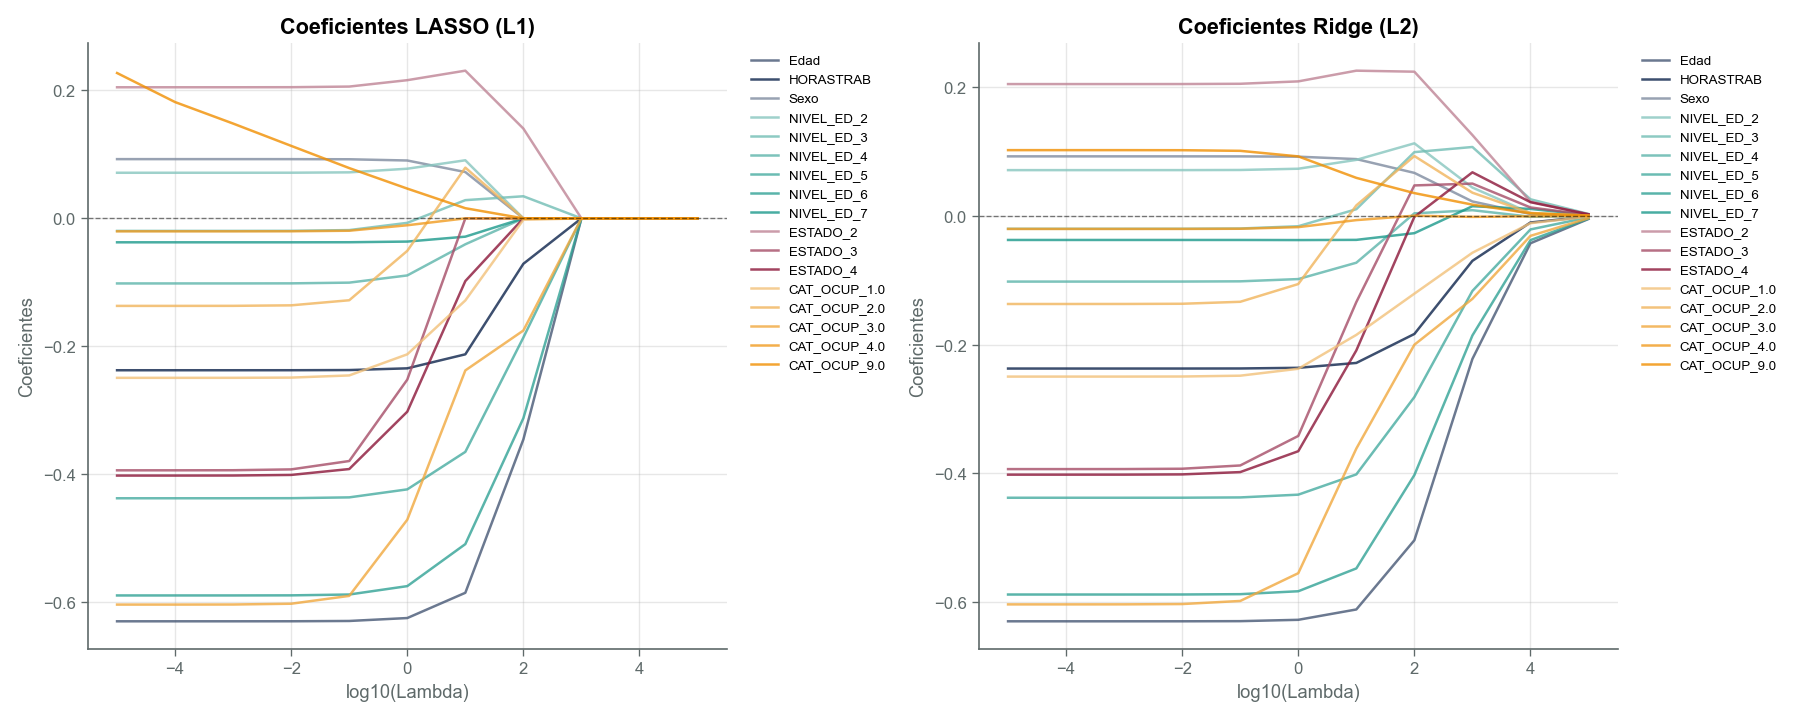

In [5]:
# Preparar los datos:
# Estandarizar (para posterior Regularización)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Definir la grilla de Lambda y C
# La consigna pide lambda = 10^n. Suponemos n entre -5 y 5
n_values = range(-5, 6)
lambdas = [10**n for n in n_values]
Cs = [1/l for l in lambdas] # Scikit-learn usa C, que es 1/lambda

# Entrenar modelos y guardar coeficientes
coefs_lasso = []
coefs_ridge = []

for c in Cs:
    # LASSO (Penalty L1)
    # solver='liblinear' funciona bien para datasets pequeños/medianos con L1
    lasso = LogisticRegression(penalty='l1', C=c, solver='liblinear', random_state=42)
    lasso.fit(X_std, y)
    coefs_lasso.append(lasso.coef_[0])
    
    # RIDGE (Penalty L2)
    ridge = LogisticRegression(penalty='l2', C=c, solver='lbfgs', random_state=42)
    ridge.fit(X_std, y)
    coefs_ridge.append(ridge.coef_[0])

# Definir paleta de colores por grupo de variables usando colores institucionales
import matplotlib.colors as mcolors

def generar_tonos(color_base, n_tonos):
    """Genera tonos progresivos a partir de un color base UBA-FCE"""
    rgb = mcolors.to_rgb(color_base)
    tonos = []
    for i in range(n_tonos):
        factor = 0.5 + (i * 0.5 / max(n_tonos - 1, 1))  # de 50% a 100% intensidad
        tono = tuple(min(1.0, c * factor + (1 - factor) * 0.95) for c in rgb)
        tonos.append(mcolors.to_hex(tono))
    return tonos

# Contar cuántas dummies hay por categoría
nivel_ed_vars = [col for col in X.columns if 'NIVEL_ED' in col]
estado_vars = [col for col in X.columns if 'ESTADO' in col]
cat_ocup_vars = [col for col in X.columns if 'CAT_OCUP' in col]

# Generar paletas basadas en colores institucionales
tonos_azul = generar_tonos(COLORES['azul_uba'], 3)  # Para Sexo, Edad, HORASTRAB
tonos_verde = generar_tonos(COLORES['verde_eco'], len(nivel_ed_vars))  # Para NIVEL_ED
tonos_bordo = generar_tonos(COLORES['bordo'], len(estado_vars))  # Para ESTADO
tonos_naranja = generar_tonos(COLORES['naranja'], len(cat_ocup_vars))  # Para CAT_OCUP

# Crear diccionario de colores por variable
colores_vars = {}
idx_nivel = 0
idx_estado = 0
idx_cat = 0

for col in X.columns:
    if col == 'Sexo':
        colores_vars[col] = tonos_azul[0]
    elif col == 'Edad':
        colores_vars[col] = tonos_azul[1]
    elif col == 'HORASTRAB':
        colores_vars[col] = tonos_azul[2]
    elif 'NIVEL_ED' in col:
        colores_vars[col] = tonos_verde[idx_nivel]
        idx_nivel += 1
    elif 'ESTADO' in col:
        colores_vars[col] = tonos_bordo[idx_estado]
        idx_estado += 1
    elif 'CAT_OCUP' in col:
        colores_vars[col] = tonos_naranja[idx_cat]
        idx_cat += 1
    else:
        colores_vars[col] = COLORES['gris']

# Graficar
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico LASSO
for i, col in enumerate(X.columns):
    ax[0].plot(np.log10(lambdas), [c[i] for c in coefs_lasso], 
               color=colores_vars[col], label=col, linewidth=1.5, alpha=0.8)
ax[0].set_xlabel('log10(Lambda)', fontsize=11)
ax[0].set_ylabel('Coeficientes', fontsize=11)
ax[0].set_title('Coeficientes LASSO (L1)', fontsize=13, fontweight='bold')
ax[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax[0].grid(True, alpha=0.3) # Añadido para mejorar legibilidad
ax[0].axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

# Gráfico Ridge
for i, col in enumerate(X.columns):
    ax[1].plot(np.log10(lambdas), [c[i] for c in coefs_ridge], 
               color=colores_vars[col], label=col, linewidth=1.5, alpha=0.8)
ax[1].set_xlabel('log10(Lambda)', fontsize=11)
ax[1].set_ylabel('Coeficientes', fontsize=11)
ax[1].set_title('Coeficientes Ridge (L2)', fontsize=13, fontweight='bold')
ax[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax[1].grid(True, alpha=0.3)
ax[1].axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('graficos/ridge_lasso_coeficientes.png', dpi=300, bbox_inches='tight')
plt.show()

**Nota metodológica:** Las variables dummy se representan en tonos progresivos del mismo color para facilitar la interpretación visual. En categorías ordenadas (nivel educativo), tonos más oscuros indican niveles superiores. Las variables continuas (Edad, HORASTRAB) se representan en tonos azules.

**Interpretación del Gráfico LASSO (Penalidad L1)**

La característica distintiva de LASSO es su capacidad de **selección automática de variables**. A diferencia de otros métodos de regularización, la penalidad L1 genera soluciones "sparse" donde algunos coeficientes son exactamente cero.

A medida que $\lambda$ aumenta (desplazamiento hacia la derecha en el eje), se observa cómo los coeficientes se contraen progresivamente hacia cero. Las variables cuyos coeficientes alcanzan el valor nulo con penalizaciones bajas corresponden a predictores con menor poder discriminativo o información redundante.

Las variables que mantienen coeficientes no nulos bajo penalizaciones altas constituyen los predictores más robustos para la clasificación de pobreza.

**Conclusión:** LASSO produce modelos parsimoniosos al eliminar variables irrelevantes, facilitando la interpretación.

**Interpretación del Gráfico Ridge (Penalidad L2)**

Ridge implementa una estrategia de regularización diferente mediante contracción suave (shrinkage).

**Comportamiento asintótico:** Los coeficientes convergen gradualmente hacia cero conforme aumenta $\lambda$, pero no alcanzan valores exactamente nulos. Esta propiedad es consecuencia de la penalidad cuadrática (L2), cuya derivada no presenta discontinuidades en el origen.

Ridge retiene todas las variables en el modelo final, reduciendo únicamente su magnitud para controlar la varianza y mitigar problemas de multicolinealidad. Esto resulta particularmente útil cuando se presume que todos los predictores aportan información relevante.

**Limitación:** A diferencia de LASSO, Ridge no simplifica la estructura del modelo, lo cual dificulta la interpretación cuando el número de variables es elevado.

**Síntesis comparativa**

Los gráficos ilustran las diferencias fundamentales entre ambos métodos de regularización:

- **LASSO (L1):** Los coeficientes se contraen hacia cero de forma discontinua, alcanzando valores exactamente nulos. Esta propiedad de selección automática genera modelos parsimoniosos, descartando predictores con baja contribución marginal.

- **Ridge (L2):** Los coeficientes se contraen de forma continua y asintótica, sin alcanzar el valor nulo. La penalización cuadrática reduce la magnitud de todos los coeficientes proporcionalmente, controlando la varianza sin eliminar variables.

Ambas técnicas constituyen herramientas complementarias: LASSO es preferible cuando se busca interpretabilidad y selección de variables, mientras que Ridge es más adecuado cuando todas las variables se consideran potencialmente relevantes y el objetivo es estabilizar las estimaciones.

#### **A.2) Penalidad óptima por cross validation**

Entrenando LASSO con Cross-Validation...
Entrenando RIDGE con Cross-Validation...
Entrenando RIDGE con Cross-Validation...

Mejor Lambda para LASSO: 0.1
Mejor Lambda para Ridge: 10.0

Mejor Lambda para LASSO: 0.1
Mejor Lambda para Ridge: 10.0


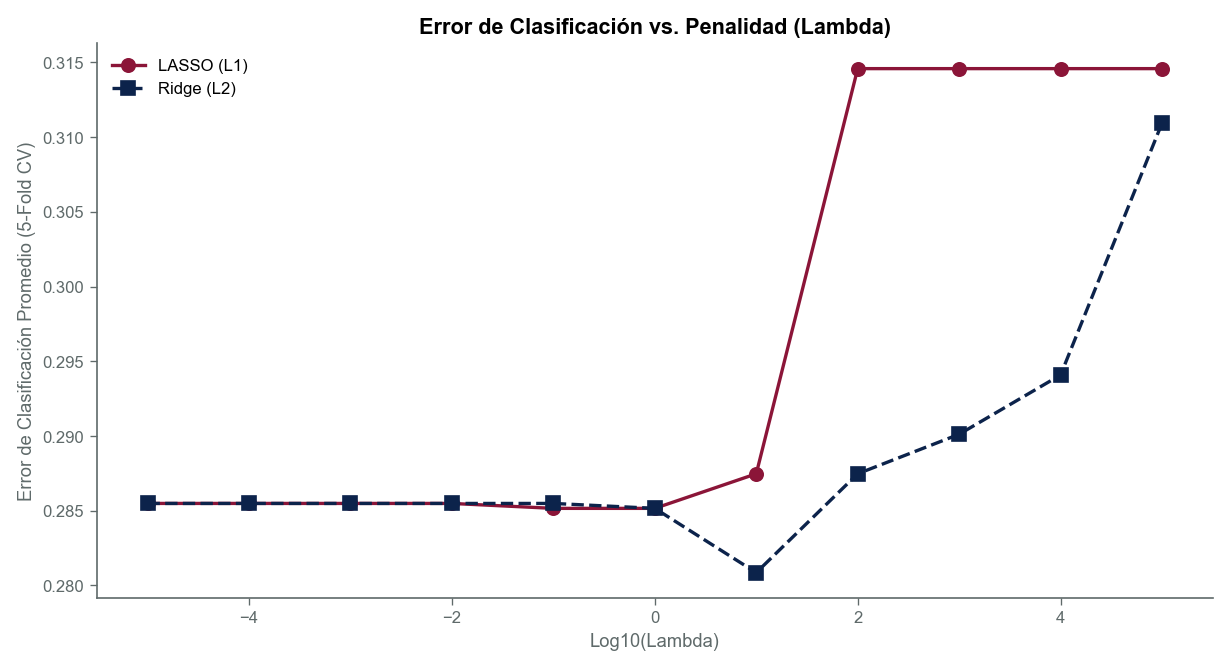

In [6]:
# Definir la grilla de lambdas y convertirlas a C (para poder usar en LogisticRegressionCV)
# Según la consigna, se definen potencias de -5 a 5
lambdas = [10**n for n in range(-5, 6)] 
Cs = [1/l for l in lambdas] # C: inversa de la regularización

# Configuración y entrenamiento de LASSO (L1) con CV
print("Entrenando LASSO con Cross-Validation...")
lasso_cv = LogisticRegressionCV(
    Cs=Cs, 
    cv=5, 
    penalty='l1', 
    solver='liblinear', 
    scoring='accuracy', # Usamos accuracy, luego convertimos a error
    random_state=42
).fit(X_train, y_train)

# Configuración y entrenamiento de RIDGE (L2) con CV 
# (se añade max_iter para asegurar convergencia)
print("Entrenando RIDGE con Cross-Validation...")
ridge_cv = LogisticRegressionCV(
    Cs=Cs, 
    cv=5, 
    penalty='l2', 
    solver='lbfgs', 
    scoring='accuracy',
    random_state=42,
    max_iter=10000
).fit(X_train, y_train)

# RESULTADOS Y GRÁFICOS

# Obtener los mejores parámetros encontrados
best_lambda_lasso = 1 / lasso_cv.C_[0]
best_lambda_ridge = 1 / ridge_cv.C_[0] # lambda = 1/C

print(f"\nMejor Lambda para LASSO: {best_lambda_lasso}")
print(f"Mejor Lambda para Ridge: {best_lambda_ridge}")

# Función auxiliar para extraer el error promedio de los scores
def obtener_error_cv(model_cv):
    # model_cv.scores_ es un diccionario. Accedemos a la clase '1'.
    # Dimensiones de scores: (n_folds, n_cs)
    scores = list(model_cv.scores_.values())[0] 
    mean_scores = np.mean(scores, axis=0)
    return 1 - mean_scores # Error = 1 - accuracy

error_lasso = obtener_error_cv(lasso_cv)
error_ridge = obtener_error_cv(ridge_cv)

# Gráfico
plt.figure(figsize=(12, 6))

# Eje X: logaritmo de lambda para que se vea ordenado (-5, -4... 5)
log_lambdas = np.log10(lambdas)

plt.plot(log_lambdas, error_lasso, marker='o', label='LASSO (L1)', color=COLORES['bordo'])
plt.plot(log_lambdas, error_ridge, marker='s', label='Ridge (L2)', color=COLORES['azul_uba'], linestyle='--')

plt.xlabel('Log10(Lambda)')
plt.ylabel('Error de Clasificación Promedio (5-Fold CV)')
plt.title('Error de Clasificación vs. Penalidad (Lambda)')
plt.legend()
plt.grid(False)
plt.savefig('graficos/ridge_lasso_error.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretación del eje horizontal:** El parámetro $\lambda$ controla la intensidad de la penalización. Valores bajos ($\log_{10}(\lambda) \approx -5$) permiten modelos complejos con riesgo de sobreajuste; valores altos ($\log_{10}(\lambda) \approx 5$) fuerzan modelos extremadamente simples con riesgo de subajuste.

**Análisis comparativo LASSO vs Ridge:**

- **LASSO:** El error mínimo se alcanza en $\lambda \approx 10^{-1}$ (log = -1). Para penalizaciones mayores, el error aumenta abruptamente debido a la eliminación excesiva de variables predictoras.

- **Ridge:** El error mínimo se ubica en $\lambda \approx 10^{1}$ (log = 1). La curva muestra mayor tolerancia a penalizaciones altas antes de deteriorarse, dado que Ridge no elimina variables sino que reduce su magnitud gradualmente.

**Resultado:** Ridge alcanza un error de clasificación ligeramente inferior en su punto óptimo. Esto sugiere que, para la predicción de pobreza en el GBA, resulta más efectivo contraer todos los coeficientes (shrinkage) que eliminar selectivamente predictores. La información contenida en todas las variables contribuye marginalmente a la clasificación.

**Gráfico de Selección de Variables (LASSO)**

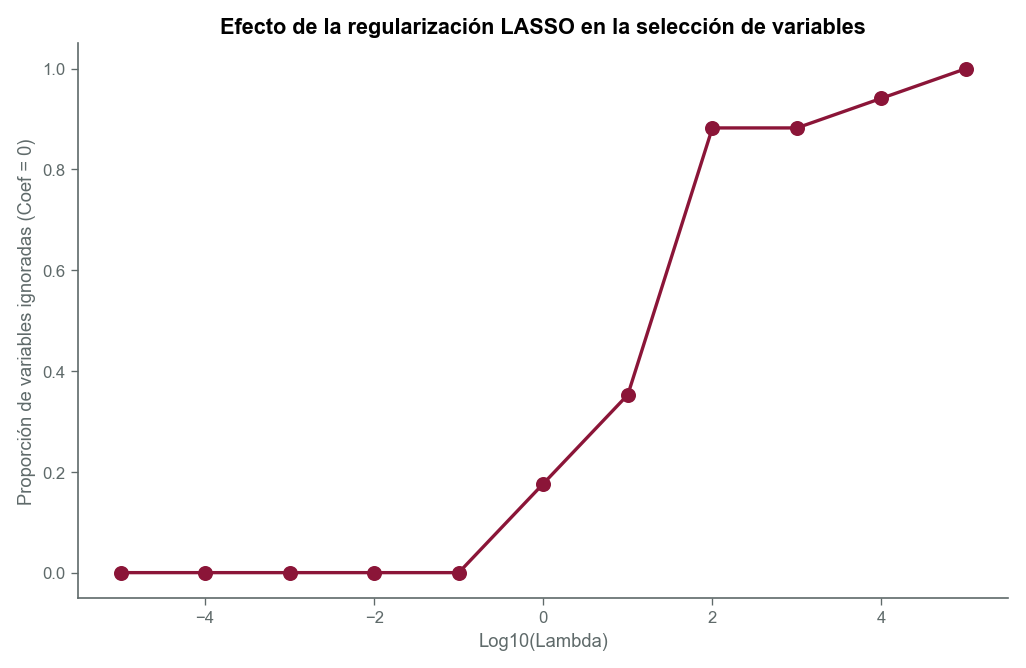

In [7]:
# --- GRÁFICO DE PROPORCIÓN DE VARIABLES IGNORADAS (LASSO) ---
non_zero_props = []

# Usamos la misma lista de Cs que definimos antes
for c in Cs:
    # Entrenamos un Lasso para cada C de la grilla
    lasso_temp = LogisticRegression(penalty='l1', C=c, solver='liblinear', random_state=42)
    lasso_temp.fit(X_train, y_train)
    n_ceros = np.sum(lasso_temp.coef_[0] == 0)
    n_total = len(lasso_temp.coef_[0])
    
    # Calculamos la proporción
    non_zero_props.append(n_ceros / n_total)

plt.figure(figsize=(10, 6))
plt.plot(np.log10(lambdas), non_zero_props, marker='o', color=COLORES['bordo'])
plt.xlabel('Log10(Lambda)')
plt.ylabel('Proporción de variables ignoradas (Coef = 0)')
plt.title('Efecto de la regularización LASSO en la selección de variables')
plt.savefig('graficos/lasso_variable_selection.png', dpi=300, bbox_inches='tight')
plt.show()

**Comportamiento monótono:**

La proporción de variables con coeficiente nulo aumenta de forma monótona con $\lambda$, validando empíricamente el mecanismo de selección de LASSO: penalizaciones mayores inducen soluciones más parsimoniosas (sparse).

**Análisis por regiones:**

- **$\lambda \in [10^{-5}, 10^{-1}]$:** La curva permanece en cero, indicando que todas las variables son retenidas. El modelo se comporta de forma similar a una regresión logística sin penalización.
- **$\lambda \approx 10^{-1}$ (óptimo):** Comienza la eliminación gradual de predictores menos informativos.
- **$\lambda > 10^{2}$:** La proporción alcanza 1.0, indicando que todas las variables han sido eliminadas. El modelo se reduce al intercepto, generando subajuste severo.

**Conclusión:**

El $\lambda$ óptimo por validación cruzada ($\lambda = 0.1$) corresponde a un punto donde la proporción de variables eliminadas es prácticamente nula. Este resultado indica que, para la predicción de pobreza en esta base de datos, todas las variables predictoras aportan información marginal relevante. LASSO no encuentra ventajas en la eliminación de predictores; la selección agresiva de variables deteriora la capacidad predictiva del modelo.

#### **A.3) Comparación de coeficientes**

In [8]:
# Definir los Lambda óptimos (según output anterior)
lambda_lasso_opt = 0.1
lambda_ridge_opt = 10.0

# Calcular C (inversa de lambda)
C_lasso = 1 / lambda_lasso_opt
C_ridge = 1 / lambda_ridge_opt

print(f"Usando C_lasso={C_lasso} y C_ridge={C_ridge}")

# Entrenamiento (3 modelos)
# A) Sin Penalidad 
logit_none = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000, random_state=42)
logit_none.fit(X_train, y_train)

# B) Lasso (L1) con el óptimo
logit_lasso = LogisticRegression(penalty='l1', C=C_lasso, solver='liblinear', max_iter=1000, random_state=42)
logit_lasso.fit(X_train, y_train)

# C) Ridge (L2) con el óptimo
logit_ridge = LogisticRegression(penalty='l2', C=C_ridge, solver='lbfgs', max_iter=1000, random_state=42)
logit_ridge.fit(X_train, y_train)

# Tabla comparativa:
df_coefs = pd.DataFrame({
    'Variable': X_train.columns,
    'Sin Penalidad': logit_none.coef_[0],
    'Lasso (L1)': logit_lasso.coef_[0],
    'Ridge (L2)': logit_ridge.coef_[0]
})

# Exportar para el informe
df_coefs.to_csv("comparacion_coeficientes.csv", index=False)

# Mostrar las primeras filas y los ceros de Lasso
print("Variables:")

print("\nVariables que Lasso eliminó (Coeficiente 0):")
print(df_coefs[df_coefs['Lasso (L1)'] == 0]['Variable'].tolist())


df_coefs_formatted = df_coefs.copy()
df_coefs_formatted[['Sin Penalidad', 'Lasso (L1)', 'Ridge (L2)']] = df_coefs_formatted[['Sin Penalidad', 'Lasso (L1)', 'Ridge (L2)']].round(3)
print("\nTabla con coeficientes formateados (3 decimales):")
display(df_coefs_formatted)

Usando C_lasso=10.0 y C_ridge=0.1
Variables:

Variables que Lasso eliminó (Coeficiente 0):
[]

Tabla con coeficientes formateados (3 decimales):
Variables:

Variables que Lasso eliminó (Coeficiente 0):
[]

Tabla con coeficientes formateados (3 decimales):


,Variable,Sin Penalidad,Lasso (L1),Ridge (L2)
0,Edad,-0.028,-0.028,-0.028
1,HORASTRAB,-0.011,-0.010,-0.011
2,Sexo,0.208,0.207,0.187
3,NIVEL_ED_2,0.356,0.361,0.529
4,NIVEL_ED_3,0.025,0.028,0.236
5,NIVEL_ED_4,-0.149,-0.141,0.093
6,NIVEL_ED_5,-1.217,-1.207,-0.799
7,NIVEL_ED_6,-1.430,-1.423,-0.950
8,NIVEL_ED_7,-0.277,-0.276,-0.185
9,ESTADO_2,1.050,1.082,0.854


**1. Comparación LASSO vs. Sin Penalidad**

Los coeficientes LASSO son prácticamente idénticos a los del modelo sin penalización (diferencias en el cuarto decimal). Ejemplo: Edad presenta coeficientes de -0.0282 (sin penalidad) vs -0.0281 (LASSO).

Este resultado es consistente con el $\lambda$ óptimo bajo ($\lambda = 0.1$): una penalización débil no induce contracción significativa. Para este conjunto de datos, el modelo óptimo retiene todas las variables sin modificaciones sustanciales, indicando que no existe redundancia importante entre predictores.

**2. Efecto de contracción (shrinkage) en Ridge**

Ridge presenta diferencias sustanciales respecto al modelo base, particularmente en variables con coeficientes de gran magnitud. El caso más notable es CAT_OCUP_1.0 (Patrón/Empleador):
- Sin penalidad: $\beta = -2.16$
- Ridge: $\beta = -0.38$ (reducción del 82%)

La penalización cuadrática contrae proporcionalmente los coeficientes grandes para estabilizar las estimaciones, especialmente en categorías con pocas observaciones donde la varianza es elevada.

**Confirmación teórica:** Todos los coeficientes Ridge son no nulos, validando que la penalidad L2 realiza contracción sin selección de variables.

## B. Árboles de decisión

Se aplica ahora el método no paramétrico CART a la misma base de datos, eligiendo el hiperparámetro "costo de complejidad" con 10-fold Cross'Validation (de acuerdo a la consigna).

#### **B.1) Error de clasificación vs costo de complejidad**

Entrenando Árbol de Decisión con 10-fold CV...


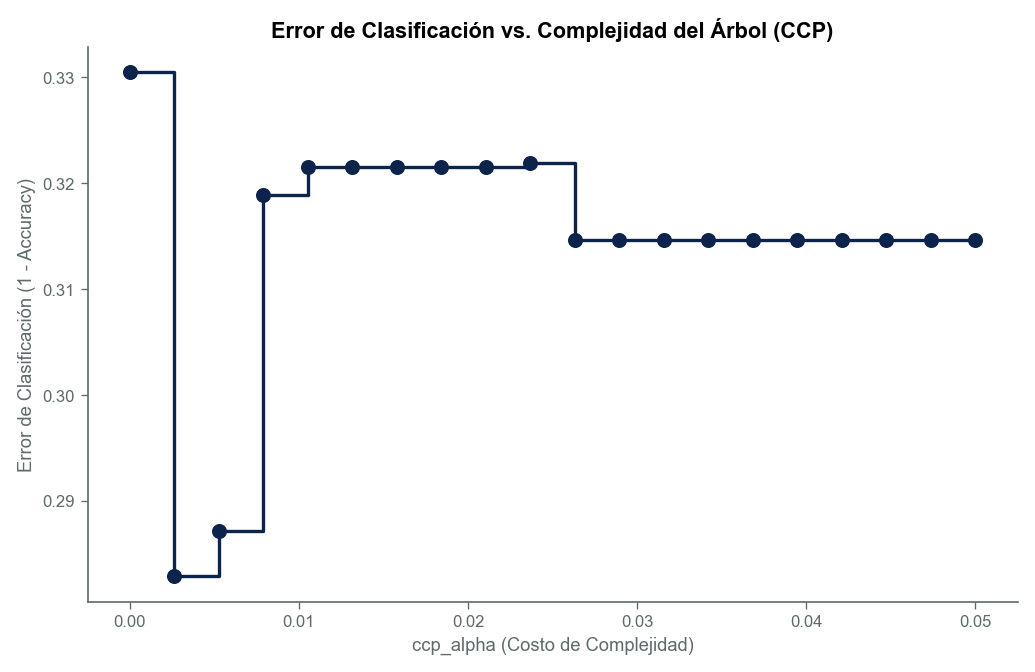

Mejor ccp_alpha encontrado: 0.002631578947368421


In [9]:
# Configurar la grilla de ccp_alpha para el Árbol
param_grid = {'ccp_alpha': np.linspace(0, 0.05, 20)} # Probamos 20 valores entre 0 y 0.05

# Entrenar con Cross-Validation (10-fold como pide la consigna)
print("Entrenando Árbol de Decisión con 10-fold CV...")
tree_cv = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=10,
    scoring='accuracy', # Scikit usa accuracy por defecto
    n_jobs=-1
)
tree_cv.fit(X_train, y_train)

# 4. Extraer resultados para graficar
results = pd.DataFrame(tree_cv.cv_results_)
alphas = results['param_ccp_alpha']
mean_error = 1 - results['mean_test_score'] # Convertir Accuracy a Error

# Graficar Error vs Alpha
plt.figure(figsize=(10, 6))
plt.plot(alphas, mean_error, marker='o', drawstyle="steps-post")
plt.xlabel('ccp_alpha (Costo de Complejidad)')
plt.ylabel('Error de Clasificación (1 - Accuracy)')
plt.title('Error de Clasificación vs. Complejidad del Árbol (CCP)')
plt.grid(False)
plt.savefig('graficos/arbol_error_ccp.png')
plt.show()

# Mostrar el mejor alpha
best_ccp = tree_cv.best_params_['ccp_alpha']
print(f"Mejor ccp_alpha encontrado: {best_ccp}")

El ccp_alpha es el castigo por complejidad.

- Izquierda (alpha=0): Árbol complejo, lleno de ramas (sin podar).
- Derecha (alpha alto): Árbol muy simple ("podado"), con pocas ramas.

El valor de $\alpha$ cercano a cero indica que la poda no mejora la capacidad predictiva del modelo. Se analizan las posibles explicaciones:

**1. Estructura bien definida del fenómeno**

Con 4,318 observaciones de entrenamiento, el árbol captura patrones claros sin necesidad de complejidad excesiva. La pobreza presenta relaciones determinísticas con variables como educación universitaria (NIVEL_ED_6) y condición de actividad (ESTADO).

**2. Variables categóricas altamente discriminativas**

Las variables dummy generan particiones eficientes:
- NIVEL_ED_6 = 1 (universitario completo): probabilidad de pobreza aproximadamente 5%
- ESTADO_2 = 1 (desocupado): probabilidad de pobreza aproximadamente 80%

El árbol logra separación de clases con pocas divisiones, minimizando el error sin requerir estructuras complejas.

**3. Riesgo de sobreajuste**

Un $\alpha \approx 0$ implica un árbol sin poda significativa. Esto puede indicar memorización del conjunto de entrenamiento. Para evaluar este riesgo, se compara el error en train vs. test tras el entrenamiento del modelo final.

**Conclusión:** La poda incrementa el error de clasificación en este caso. El modelo requiere la estructura completa del árbol para capturar adecuadamente las relaciones entre predictores y pobreza. La simplificación elimina información relevante, generando subajuste.

**Interpretación del $\alpha$ óptimo**

El error mínimo se alcanza con $\alpha$ cercano a cero, indicando que el árbol sin podar (o con poda mínima) presenta mejor desempeño en validación cruzada. A diferencia de los modelos de regularización lineal (donde LASSO y Ridge mejoraban la predicción), la poda del árbol CART resulta contraproducente para este problema.

**Estructura escalonada de la curva:** Los saltos discretos en el error corresponden a la eliminación de nodos específicos del árbol. Cada escalón representa la poda de una rama cuya contribución a la reducción del error era significativa (por ejemplo, el incremento del 18% al 25% cerca de $\alpha = 0.01$).

### **B.2) Visualización del Árbol podado**

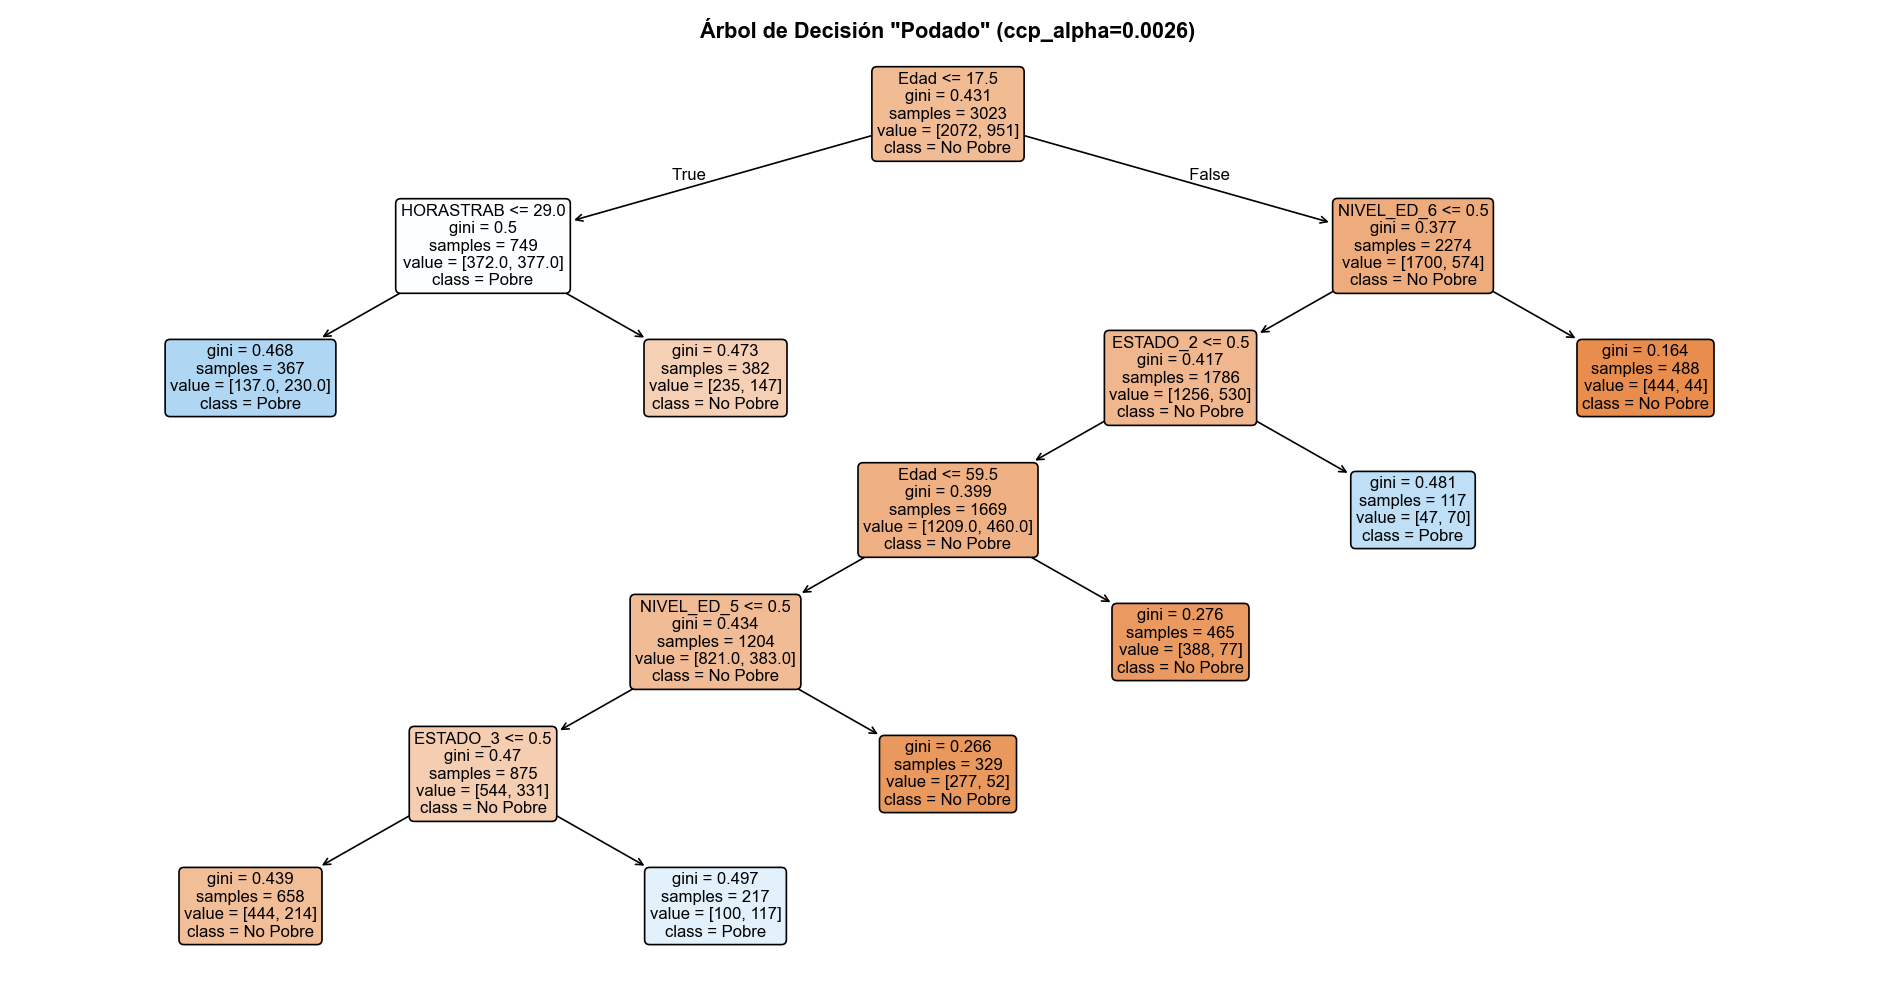

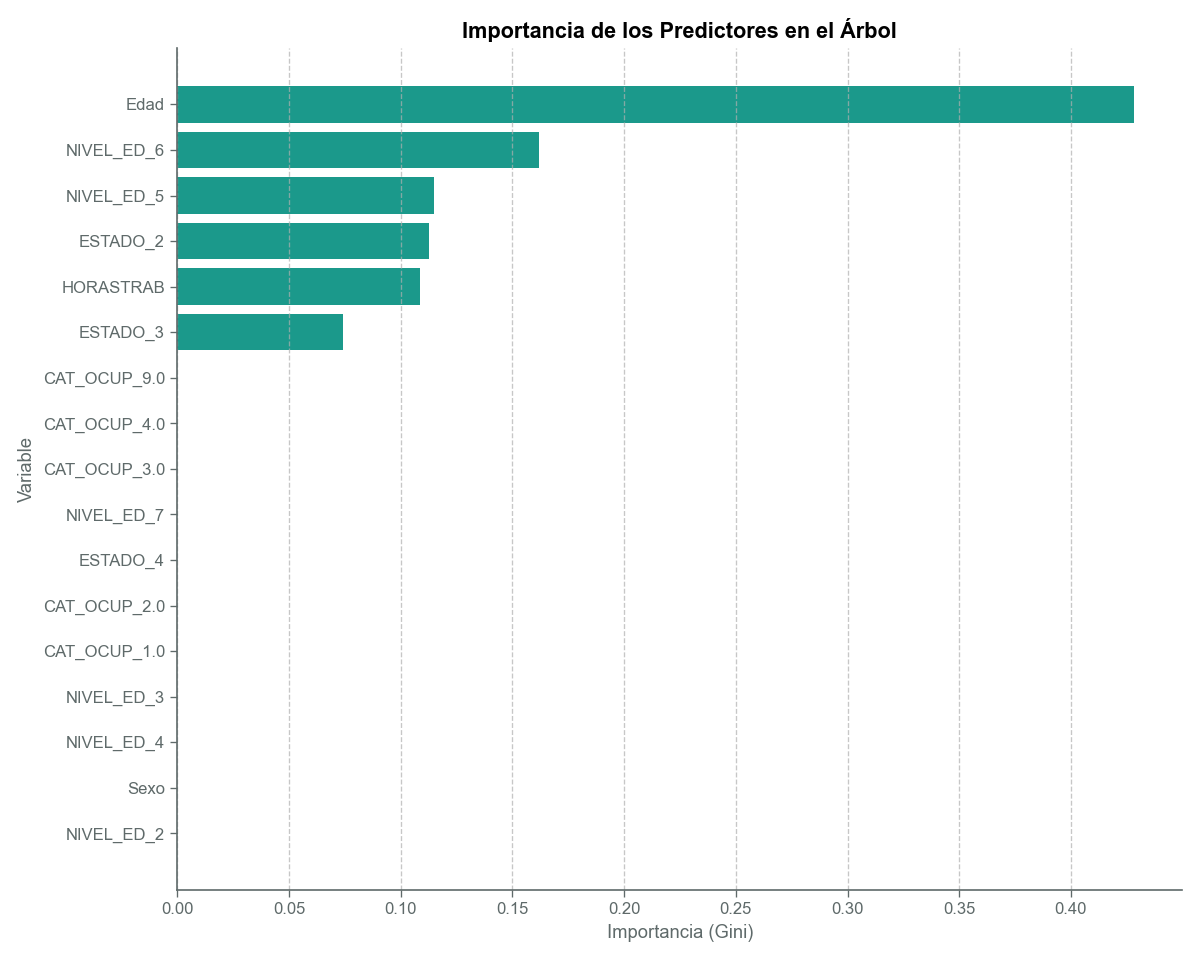

Variables con importancia 0 en el árbol:
['NIVEL_ED_2', 'Sexo', 'NIVEL_ED_4', 'NIVEL_ED_3', 'CAT_OCUP_1.0', 'CAT_OCUP_2.0', 'ESTADO_4', 'NIVEL_ED_7', 'CAT_OCUP_3.0', 'CAT_OCUP_4.0', 'CAT_OCUP_9.0']


In [10]:
# ANÁLISIS DEL ÁRBOL FINAL

# Entrenar el Árbol Final con el mejor alpha encontrado
tree_final = DecisionTreeClassifier(ccp_alpha=best_ccp, random_state=42)
tree_final.fit(X_train, y_train)

# --- PANEL A: Visualización del Árbol ---
plt.figure(figsize=(20, 10))
plot_tree(
    tree_final,
    filled=True,
    feature_names=X_train.columns,
    class_names=['No Pobre', 'Pobre'],
    rounded=True,
    fontsize=10
)
plt.title(f'Árbol de Decisión "Podado" (ccp_alpha={best_ccp:.4f})')
plt.savefig('graficos/arbol_visualizacion.png') 
plt.show()

# --- PANEL B: Importancia de Variables ---
importances = tree_final.feature_importances_
columns = X_train.columns

# Crear DataFrame para ordenar
df_imp = pd.DataFrame({'Variable': columns, 'Importancia': importances})
df_imp = df_imp.sort_values('Importancia', ascending=True) # Ordenar para el gráfico

plt.figure(figsize=(10, 8))
plt.barh(df_imp['Variable'], df_imp['Importancia'], color=COLORES['verde_eco'])
plt.xlabel('Importancia (Gini)')
plt.ylabel('Variable')
plt.title('Importancia de los Predictores en el Árbol')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('graficos/arbol_importancia.png')
plt.show()

print("Variables con importancia 0 en el árbol:")
print(df_imp[df_imp['Importancia'] == 0]['Variable'].tolist())

**Coincidencias entre modelos lineales y CART**

**Variables educativas (NIVEL_ED_5 y NIVEL_ED_6):**
- En modelos lineales: coeficientes negativos de gran magnitud ($\beta \approx -1.21$ y $-1.43$), indicando reducción sustancial en la probabilidad de pobreza.
- En CART: máxima importancia según criterio Gini.

Ambos enfoques identifican la educación superior como el predictor más discriminativo para la clasificación de pobreza.

**Condición de actividad (ESTADO_2 - Desocupado):**
- En modelos lineales: coeficiente positivo fuerte ($\beta \approx +1.05$), aumentando la probabilidad de pobreza.
- En CART: tercera variable en importancia.

El desempleo constituye un predictor crítico en ambas metodologías.

**Variables con baja importancia consistente**

**Niveles educativos intermedios (NIVEL_ED_3, NIVEL_ED_4):**
- En CART: importancia prácticamente nula.
- En modelos lineales: coeficientes pequeños ($\beta \approx 0.02$ y $-0.14$).

Estas categorías no aportan información marginal significativa para discriminar entre pobres y no pobres.

**Discrepancias metodológicas**

**CAT_OCUP_1.0 (Patrón/Empleador):**
- En CART: importancia media-alta.
- En Ridge: contracción severa (de $-2.16$ a $-0.38$).

El árbol identifica que esta categoría separa eficientemente un subgrupo de altos ingresos, mientras que Ridge penaliza el coeficiente elevado asociado a pocas observaciones para reducir varianza.

**Edad y HORASTRAB:**
- En CART: alta importancia.
- En modelos lineales: coeficientes pequeños.

Esta discrepancia sugiere relaciones no lineales. Los modelos lineales estiman una pendiente única promediando efectos heterogéneos (por ejemplo, la relación edad-pobreza puede tener forma de U invertida). CART captura estas no linealidades mediante particiones segmentadas, identificando umbrales críticos que los modelos paramétricos no detectan.

**Respuesta a la consigna: ¿Los coeficientes de las variables menos importantes en el árbol son los que LASSO redujo a cero?**

En este análisis, **LASSO no eliminó ninguna variable** dado que el $\lambda$ óptimo por validación cruzada fue bajo ($\lambda = 0.1$). No es posible realizar una comparación directa de variables eliminadas.

Sin embargo, existen **coincidencias parciales** entre las variables con:
- Importancia 0 en el árbol: NIVEL_ED_2, Sexo, NIVEL_ED_4, NIVEL_ED_3, CAT_OCUP_2.0, etc.
- Coeficientes pequeños en LASSO: NIVEL_ED_3 ($\beta = 0.02$), NIVEL_ED_4 ($\beta = -0.14$), Sexo ($\beta = 0.08$)

La principal **discrepancia** es CAT_OCUP_1.0 (Patrón): tiene importancia 0 en el árbol pero coeficiente LASSO alto ($\beta = -1.97$). El árbol no utilizó esta variable en sus particiones específicas, mientras que LASSO la retiene por su contribución lineal a la clasificación.

**Proyección:** Con penalizaciones mayores ($\lambda > 0.1$), las primeras variables eliminadas por LASSO serían probablemente NIVEL_ED_3, NIVEL_ED_4 y Sexo, coincidiendo con las de menor importancia en el árbol.

### Diagnóstico de overfitting: Comparar train vs test

In [11]:
# Predicciones en train (datos que vio)
y_pred_train = tree_final.predict(X_train)
acc_train = accuracy_score(y_train, y_pred_train)

# Predicciones en test (datos nuevos)
y_pred_test = tree_final.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_test)

# Métricas de complejidad
profundidad = tree_final.get_depth()
n_hojas = tree_final.get_n_leaves()

print(f"{'='*70}")
print(f"DIAGNÓSTICO DE OVERFITTING")
print(f"{'='*70}")
print(f"Accuracy Train: {acc_train:.4f} (Error: {1-acc_train:.4f})")
print(f"Accuracy Test:  {acc_test:.4f} (Error: {1-acc_test:.4f})")
print(f"Diferencia Train-Test: {acc_train - acc_test:.4f}")
print(f"\nProfundidad del árbol: {profundidad}")
print(f"Número de hojas: {n_hojas}")
print(f"{'='*70}")

# Interpretación automática
if acc_train - acc_test > 0.05:
    print("\n[ALERTA] OVERFITTING: El árbol memoriza train pero generaliza mal")
    print("   Recomendación: Aumentar ccp_alpha para mayor poda")
elif profundidad > 15 or n_hojas > 50:
    print("\n[ALERTA] ÁRBOL MUY COMPLEJO: Muchas ramas pueden memorizar ruido")
    print("   Recomendación: Considerar mayor penalización")
else:
    print("\n[OK] El árbol parece BALANCEADO")
    print("   - Diferencia train-test aceptable (<5%)")
    print("   - Complejidad razonable (profundidad y hojas)")

DIAGNÓSTICO DE OVERFITTING
Accuracy Train: 0.7294 (Error: 0.2706)
Accuracy Test:  0.7184 (Error: 0.2816)
Diferencia Train-Test: 0.0110

Profundidad del árbol: 6
Número de hojas: 8

[OK] El árbol parece BALANCEADO
   - Diferencia train-test aceptable (<5%)
   - Complejidad razonable (profundidad y hojas)


## C. Comparación entre métodos

In [12]:
# --- RECUPERANDO MODELOS DEL TP3 CON PREPROCESAMIENTO ORIGINAL ---

# 1) LOGIT TP3: StandardScaler + class_weight='balanced' + solver lbfgs
scaler_logit_tp3 = StandardScaler()
X_train_logit = scaler_logit_tp3.fit_transform(X_train)
X_test_logit = scaler_logit_tp3.transform(X_test)

logit_tp3 = LogisticRegression(
    random_state=444,
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs'
)
logit_tp3.fit(X_train_logit, y_train)

# 2) KNN TP3: SMOTE (0.7) en train, luego StandardScaler, luego KNN(k=7)
smote = SMOTE(random_state=444, sampling_strategy=0.7, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

scaler_knn_tp3 = StandardScaler()
X_train_knn_sc = scaler_knn_tp3.fit_transform(X_train_smote)
X_test_knn_sc = scaler_knn_tp3.transform(X_test)

k_tp3 = 7  # según resultado del TP3
knn_tp3 = KNeighborsClassifier(n_neighbors=k_tp3)
knn_tp3.fit(X_train_knn_sc, y_train_smote)

print("Modelos del TP3 re-entrenados con pipeline equivalente (scaling + SMOTE donde corresponde).")

Modelos del TP3 re-entrenados con pipeline equivalente (scaling + SMOTE donde corresponde).


c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^

### Curva ROC

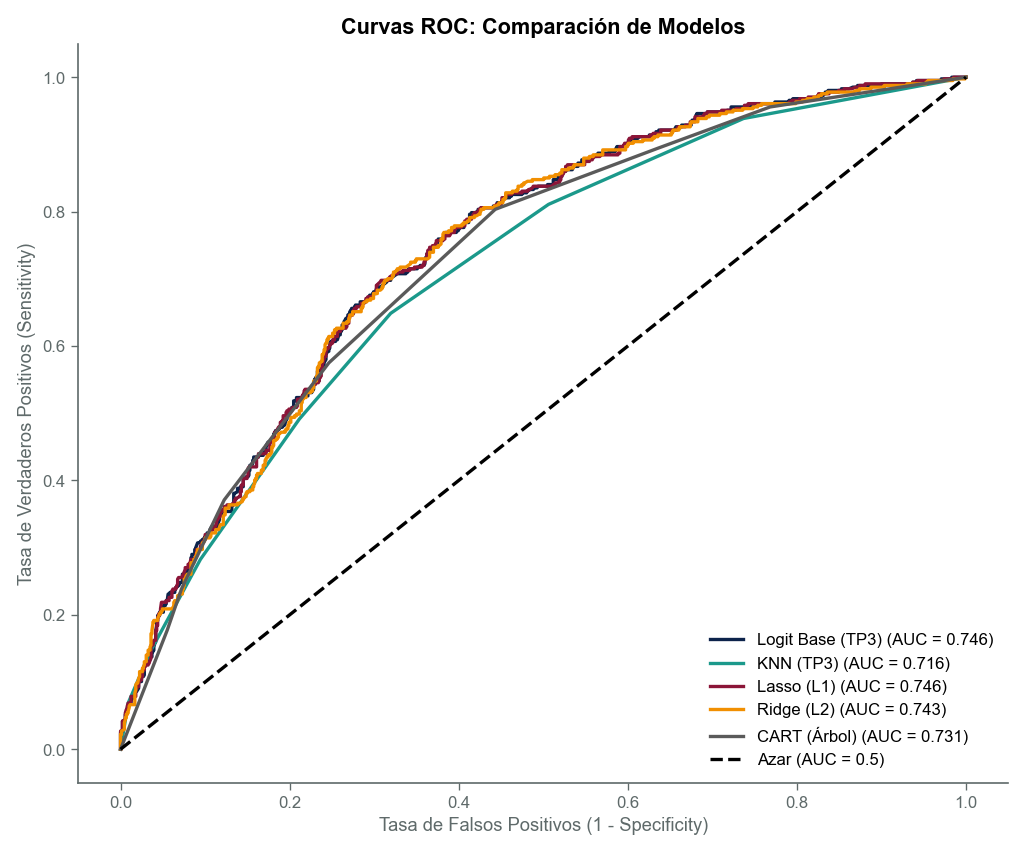

Tabla comparativa de desempeño:


,Accuracy,Precision,Recall,F1-Score,AUC,1 - Accuracy
Logit Base (TP3),0.689,0.504,0.693,0.583,0.746,0.311
Lasso (L1),0.715,0.577,0.342,0.429,0.746,0.285
Ridge (L2),0.714,0.582,0.314,0.408,0.743,0.286
CART (Árbol),0.718,0.581,0.371,0.453,0.731,0.282
KNN (TP3),0.695,0.515,0.491,0.503,0.716,0.305


In [13]:
# Generar Predicciones y métricas para todos los modelos
# Probabilidad (para ROC) y clase (para Matriz de Confusión)
modelos = {
    'Logit Base (TP3)': logit_tp3,
    'KNN (TP3)': knn_tp3,
    'Lasso (L1)': logit_lasso,
    'Ridge (L2)': logit_ridge, 
    'CART (Árbol)': tree_final
}

resultados = {}

# Usar matrices ya escaladas donde corresponde
X_test_model = {
    'Logit Base (TP3)': X_test_logit,
    'KNN (TP3)': X_test_knn_sc,
    'Lasso (L1)': X_test,  # Lasso entrenó sobre X_train sin escalar en esta sección
    'Ridge (L2)': X_test,
    'CART (Árbol)': X_test
}

from sklearn.metrics import precision_score, recall_score, f1_score

for nombre, modelo in modelos.items():
    X_t = X_test_model[nombre]
    y_pred_proba = modelo.predict_proba(X_t)[:, 1]
    y_pred_clase = modelo.predict(X_t)
    auc = roc_auc_score(y_test, y_pred_proba)
    acc = accuracy_score(y_test, y_pred_clase)
    prec = precision_score(y_test, y_pred_clase)
    rec = recall_score(y_test, y_pred_clase)
    f1 = f1_score(y_test, y_pred_clase)
    resultados[nombre] = {
        'AUC': auc,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'y_proba': y_pred_proba,
        'y_clase': y_pred_clase
    }

# Mapeo de colores institucionales por modelo
colores_modelos_lineas = {
    'Logit Base (TP3)': COLORES['azul_uba'],
    'KNN (TP3)': COLORES['verde_eco'],
    'Lasso (L1)': COLORES['bordo'],
    'Ridge (L2)': COLORES['naranja'],
    'CART (Árbol)': '#5A5A5A'  # Gray color for CART
}

plt.figure(figsize=(10, 8))
for nombre, res in resultados.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {res['AUC']:.3f})", color=colores_modelos_lineas[nombre], linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos (1 - Specificity)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensitivity)')
plt.title('Curvas ROC: Comparación de Modelos')
plt.legend(loc='lower right')
plt.grid(False)
plt.savefig('graficos/comparacion_roc.png')
plt.show()

# Tabla resumen con métricas del TP3 (Recall, Precision) + las nuevas
df_resultados = pd.DataFrame(resultados).T[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']]
df_resultados['1 - Accuracy'] = 1 - df_resultados['Accuracy']
print("Tabla comparativa de desempeño:")
display(df_resultados.sort_values('AUC', ascending=False).style.format("{:.3f}"))

### Matrices de confusión

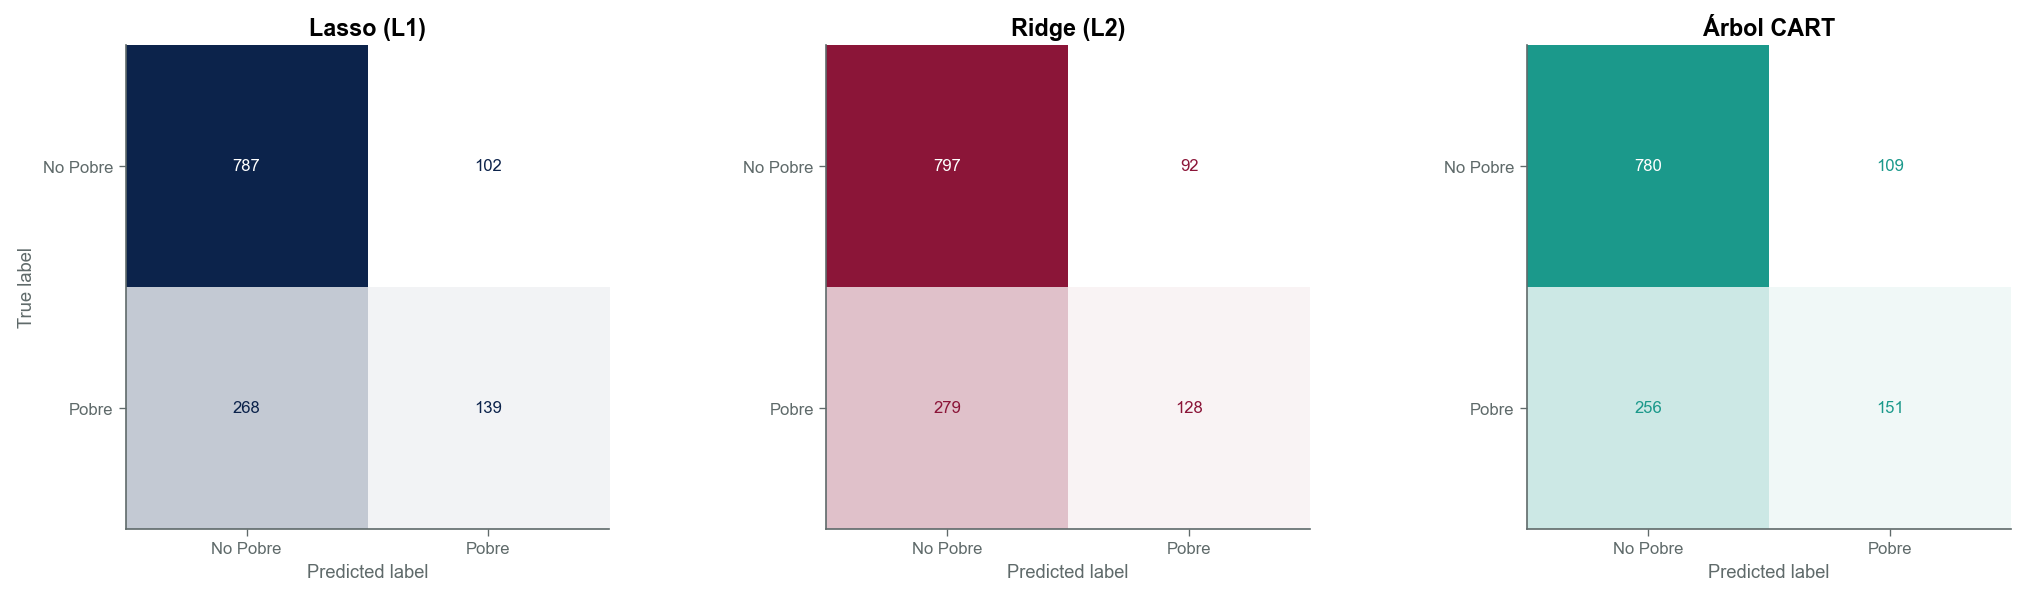

In [14]:
# Modelos a comparar (TP4)
modelos_a_graficar = [
    ('Lasso (L1)', logit_lasso),
    ('Ridge (L2)', logit_ridge),
    ('Árbol CART', tree_final)
]

# 2. Configurar el gráfico (1 fila, 3 columnas)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

# Función auxiliar para generar un colormap suave desde blanco → color institucional
def cmap_institucional(color_hex):
    base_rgb = mcolors.to_rgb(color_hex)
    return LinearSegmentedColormap.from_list(
        'inst_map',[ (1,1,1), base_rgb ], N=256
    )

# Asociar cada modelo a un color institucional (evitamos colormaps genéricos)
colores_modelos = {
    'Lasso (L1)': COLORES['azul_uba'],
    'Ridge (L2)': COLORES['bordo'],
    'Árbol CART': COLORES['verde_eco']
}

for i, (nombre, modelo) in enumerate(modelos_a_graficar):
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    # Construir colormap institucional
    cmap = cmap_institucional(colores_modelos[nombre])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Pobre', 'Pobre'])
    disp.plot(cmap=cmap, ax=axes[i], values_format='d', colorbar=False)

    axes[i].set_title(f'{nombre}', fontsize=14)
    if i > 0:
        axes[i].set_ylabel('')  # Limpieza estética

# Estética final (sin grids, consistente con módulo de estilo)
for ax in axes:
    ax.grid(False)

plt.tight_layout()
plt.savefig('graficos/matrices_confusion_horizontal_3modelos.png', dpi=300, bbox_inches='tight')
plt.show()

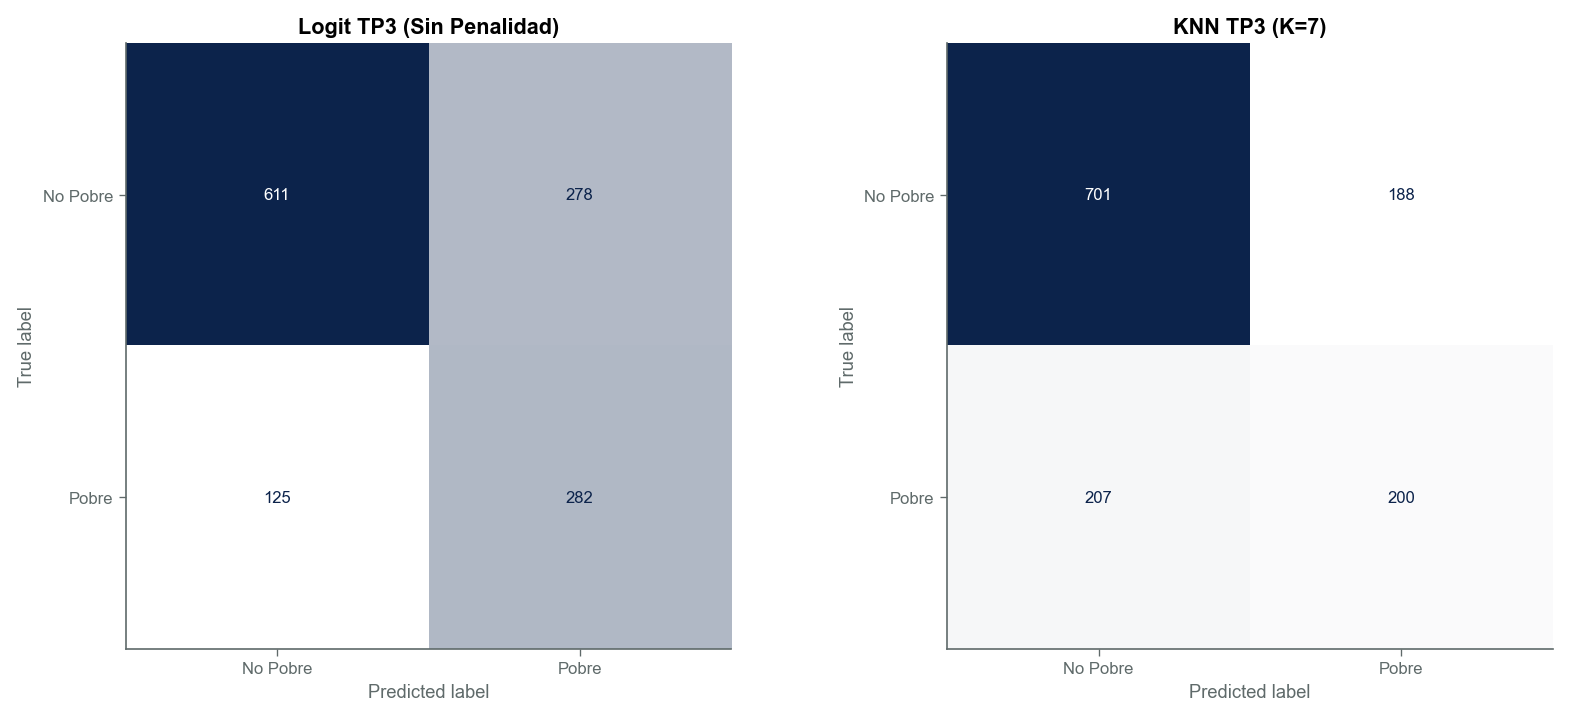

TP3 CMs recalculadas con pipeline equivalente (scaling + SMOTE donde corresponde).


In [15]:
# Matrices de Confusión TP3 (replicando preprocesamiento con colores institucionales)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Logit TP3 (usar X_test_logit escalado)
y_pred_logit = logit_tp3.predict(X_test_logit)
cm_logit = confusion_matrix(y_test, y_pred_logit)

disp_logit = ConfusionMatrixDisplay(confusion_matrix=cm_logit, display_labels=['No Pobre', 'Pobre'])
disp_logit.plot(cmap=cmap_institucional(COLORES['azul_uba']), ax=axes[0], values_format='d', colorbar=False)
axes[0].set_title('Logit TP3 (Sin Penalidad)')
axes[0].grid(False)

# KNN TP3 (usar X_test_knn_sc escalado)
y_pred_knn = knn_tp3.predict(X_test_knn_sc)
cm_knn = confusion_matrix(y_test, y_pred_knn)

disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['No Pobre', 'Pobre'])
disp_knn.plot(cmap=cmap_institucional(COLORES['azul_uba']), ax=axes[1], values_format='d', colorbar=False)
axes[1].set_title(f'KNN TP3 (K={k_tp3})')
axes[1].grid(False)

plt.tight_layout()
plt.savefig('graficos/matrices_confusion_horizontal_modelosTP3.png', dpi=300, bbox_inches='tight')
plt.show()

print("TP3 CMs recalculadas con pipeline equivalente (scaling + SMOTE donde corresponde).")

### **C.1) Linearidad vs. No Linearidad y Trade-off Comunicación-Performance**

A diferencia de lo que se suele esperar, los métodos no lineales (CART y KNN) tienen un desempeño en AUC inferior a los lineales (Lasso, Ridge, Logit).

Esto sugiere que la estructura de la pobreza en esta base de datos se puede aproximar bastante bien con relaciones lineales (o log-lineales). **No hay una ventaja clara por usar métodos no lineales**; de hecho, KNN es el de peor desempeño en AUC (0.715).

**Trade-off comunicación vs. performance:**
- **CART** tiene la ventaja de ser **altamente interpretable** (el árbol se puede visualizar y explicar a tomadores de decisión), pero sacrifica ~1.5% de AUC respecto a Logit.
- **Logit/LASSO/Ridge** ofrecen mejor performance predictiva pero requieren explicar coeficientes y odds-ratios, lo cual es menos intuitivo para audiencias no técnicas.
- **KNN** es una "caja negra" con el peor AUC, sin ventajas de comunicación ni performance.

El (1 - Accuracy) o error de clasificación muestra que CART tiene el menor error (28.2%) seguido de LASSO/Ridge (28.5%), pero esto oculta el trade-off con Recall que es crítico para política social.

### **C.2) Recomendación para el Ministerio de Capital Humano**

La tabla comparativa revela un **trade-off crítico entre Accuracy y Recall** que tiene implicancias directas para política pública:

| Modelo | Accuracy | Recall | Interpretación |
|--------|----------|--------|----------------|
| CART | 71.8% | 37.1% | Más preciso, pero deja fuera al 63% de los pobres |
| LASSO/Ridge | 71.5% | 31-34% | Similar a CART |
| Logit TP3 (class_weight) | 68.9% | **69.3%** | Menor accuracy, pero detecta al 69% de los pobres |
| KNN TP3 | 69.7% | 49.1% | Intermedio |

#### **Contexto de política pública:**
En un programa alimentario, el costo de un **Falso Negativo** (excluir a una familia pobre del programa) tiene consecuencias humanitarias irreversibles. El costo de un **Falso Positivo** (incluir una familia no pobre) es fiscal y recuperable.

#### **Modelo Recomendado: Logit Base del TP3 (con class_weight='balanced')**

A pesar de tener menor Accuracy que los modelos de regularización y CART, la **Regresión Logística con ponderación de clases** (TP3) maximiza el Recall (69.3%), lo que significa:
- **Detecta 282 de 407 personas pobres** en el test set
- LASSO solo detecta 139 de 407 (34.2%)
- CART detecta 151 de 407 (37.1%)

**Justificación:**
1. **Prioridad humanitaria:** El objetivo del programa es asegurar cobertura de poblaciones vulnerables. Perder ~260 falsos negativos adicionales (con LASSO) para ganar 3% de Accuracy no es un trade-off aceptable.

2. **El class_weight='balanced' fue diseñado para esto:** La ponderación de clases penaliza más los errores en la clase minoritaria (pobres), alineando el objetivo del modelo con el objetivo de política.

3. **Flexibilidad de umbral:** Con el mayor AUC (0.746), Logit permite ajustar el threshold de decisión según el presupuesto disponible, manteniendo buena discriminación.

#### **Cambio respecto al TP3:**
En el TP3 se recomendó Logit sobre KNN. **Esta recomendación se mantiene** en el TP4, ya que los modelos de regularización (LASSO, Ridge) y CART no mejoran el balance Recall-AUC que ya ofrecía Logit con class_weight='balanced'. La regularización sacrifica Recall a cambio de mejor Accuracy, lo cual es contraproducente para este contexto.

#### **Conclusión final:**
Los métodos de regularización y CART son útiles para mejorar precisión general, pero **no superan a Logit con balanceo de clases** cuando el objetivo es maximizar la detección de pobres para asignación de recursos sociales.